In [4]:
!pip install -q segmentation-models-pytorch albumentations timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.6 MB/s eta 0:00:00


In [ ]:
#necessary imports

from src.dataset import build_dataloaders
from src.trainer import train_model
from src.metrics import MetricsTracker
from models.unetplusplus import UNetPlusPlus
from models.transunet import TransUNet
import os, sys, torch, cv2
import json
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#setup paths and data
#adding current directory to path so we can import from src/ and models/
sys.path.append(os.getcwd())

DATA_DIR = './data'
IMG_DIR  = os.path.join(DATA_DIR, 'ISIC2018_Task1-2_Training_Input')
MASK_DIR = os.path.join(DATA_DIR, 'ISIC2018_Task1_Training_GroundTruth')

#download data logic
if not os.path.exists(IMG_DIR):
    os.system('wget -q "https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task1-2_Training_Input.zip" -O images.zip')
    os.system(f'unzip -q images.zip -d {DATA_DIR} && rm images.zip')
    os.system('wget -q "https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task1_Training_GroundTruth.zip" -O masks.zip')
    os.system(f'unzip -q masks.zip -d {DATA_DIR} && rm masks.zip')
    print("Download complete.")

📥 Data missing. Downloading ISIC 2018...
✅ Download complete.


In [ ]:
#setting variables

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 256
EPOCHS = 100

In [ ]:
#data loader

train_loader, val_loader, test_loader = build_dataloaders(
    IMG_DIR, MASK_DIR, img_size=IMG_SIZE, batch_size=16)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
#training unet++

unetpp = UNetPlusPlus(deep_supervision=True)
hist_up = train_model(unetpp, 'UNetPP', train_loader, val_loader, epochs=EPOCHS, lr=1e-3, device=device, is_deep_sup=True)


🚀 Starting UNet++ Training...


W0505 10:36:10.017000 8600 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[UNetPP] Ep 1/10 | Loss: 0.3086/0.2484 | Dice: 0.6180/0.6833 | LR: 2.01e-04
[UNetPP] Ep 2/10 | Loss: 0.2501/0.2084 | Dice: 0.7075/0.7734 | LR: 4.01e-04
[UNetPP] Ep 3/10 | Loss: 0.2390/0.2260 | Dice: 0.7122/0.7117 | LR: 6.00e-04
[UNetPP] Ep 4/10 | Loss: 0.2262/0.2039 | Dice: 0.7230/0.7309 | LR: 8.00e-04
[UNetPP] Ep 5/10 | Loss: 0.2275/0.2294 | Dice: 0.7130/0.7055 | LR: 1.00e-03
[UNetPP] Ep 6/10 | Loss: 0.2163/0.1850 | Dice: 0.7219/0.7707 | LR: 9.05e-04
[UNetPP] Ep 7/10 | Loss: 0.2086/0.1775 | Dice: 0.7356/0.7839 | LR: 6.55e-04
[UNetPP] Ep 8/10 | Loss: 0.2019/0.1690 | Dice: 0.7490/0.8062 | LR: 3.46e-04
[UNetPP] Ep 9/10 | Loss: 0.1818/0.1597 | Dice: 0.7699/0.7995 | LR: 9.64e-05
[UNetPP] Ep 10/10 | Loss: 0.1766/0.1492 | Dice: 0.7816/0.8157 | LR: 1.00e-06
✅ UNetPP Training Complete. Best Val Dice: 0.8157 Time: 60.1m


In [15]:
import importlib
import models.transunet

importlib.reload(models.transunet)
from models.transunet import TransUNet

In [ ]:
#transunet training

transunet = TransUNet(img_size=IMG_SIZE, n_layers=4)
hist_tu = train_model(transunet, 'TransUNet', train_loader, val_loader, epochs=EPOCHS, lr=1e-4, device=device, is_deep_sup=False)



🚀 Starting TransUNet Training (Optimized with 4 layers)...
[TransUNet] Ep 1/10 | Loss: 0.2457/0.1936 | Dice: 0.6749/0.7612 | LR: 2.08e-05
[TransUNet] Ep 2/10 | Loss: 0.1631/0.1689 | Dice: 0.7829/0.7879 | LR: 4.06e-05
[TransUNet] Ep 3/10 | Loss: 0.1572/0.1733 | Dice: 0.7918/0.7913 | LR: 6.04e-05
[TransUNet] Ep 4/10 | Loss: 0.1567/0.1614 | Dice: 0.7929/0.7956 | LR: 8.02e-05
[TransUNet] Ep 5/10 | Loss: 0.1500/0.1654 | Dice: 0.8028/0.7916 | LR: 1.00e-04
[TransUNet] Ep 6/10 | Loss: 0.1497/0.1625 | Dice: 0.8041/0.8090 | LR: 9.05e-05
[TransUNet] Ep 7/10 | Loss: 0.1428/0.1473 | Dice: 0.8093/0.8013 | LR: 6.58e-05
[TransUNet] Ep 8/10 | Loss: 0.1318/0.1480 | Dice: 0.8245/0.8276 | LR: 3.52e-05
[TransUNet] Ep 9/10 | Loss: 0.1223/0.1303 | Dice: 0.8362/0.8387 | LR: 1.05e-05
[TransUNet] Ep 10/10 | Loss: 0.1150/0.1270 | Dice: 0.8453/0.8440 | LR: 1.00e-06
✅ TransUNet Training Complete. Best Val Dice: 0.8440 Time: 59.1m


In [ ]:
#final evaluation

#results directories
RESULT_DIR = './results'
os.makedirs(os.path.join(RESULT_DIR, 'UNetPP'), exist_ok=True)
os.makedirs(os.path.join(RESULT_DIR, 'TransUNet'), exist_ok=True)
os.makedirs(os.path.join(RESULT_DIR, 'Comparison'), exist_ok=True)

def evaluate_and_save(model, name, loader, path, is_ds=False):
    state_dict = torch.load(path, map_location=device)
    cleaned_state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}
    model.load_state_dict(cleaned_state_dict)
    model = model.to(device)
    model.eval()

    tracker = MetricsTracker(compute_hd=True)
    save_path = os.path.join(RESULT_DIR, name)

    with torch.no_grad():
        for i, (imgs, msks) in enumerate(loader):
            imgs, msks = imgs.to(device), msks.to(device)
            out = model(imgs)
            if is_ds and isinstance(out, list): out = out[-1]
            tracker.update(out, msks)

            # saving only predictions of first five images
            if i < 5:
                pred = (torch.sigmoid(out[0,0]).cpu().numpy() > 0.5).astype(np.uint8) * 255
                cv2.imwrite(os.path.join(save_path, f'pred_{i}.png'), pred)

    res = tracker.compute()

    with open(os.path.join(save_path, 'metrics.json'), 'w') as f:
        json.dump(res, f, indent=4)

    # detailed metrics
    print(f"\n" + "-"*50)
    print(f"  {name} Detailed Evaluation Results")
    print("-" * 50)
    for k, v in res.items():
        print(f"  {k:<10} : {v:.4f}")
    print("-" * 50)
    return res

res_up = evaluate_and_save(UNetPlusPlus(), 'UNetPP', test_loader, 'UNetPP_best.pth', True)
res_tu = evaluate_and_save(TransUNet(img_size=IMG_SIZE), 'TransUNet', test_loader, 'TransUNet_best.pth', False)



🧪 Evaluating UNetPP...

--------------------------------------------------
  UNetPP Detailed Evaluation Results
--------------------------------------------------
  Dice       : 0.8129
  IoU        : 0.7190
  Sens       : 0.8513
  Spec       : 0.9693
  HD95       : 18.2084
--------------------------------------------------
✅ UNetPP Metrics saved to ./results/UNetPP/metrics.json

🧪 Evaluating TransUNet...

--------------------------------------------------
  TransUNet Detailed Evaluation Results
--------------------------------------------------
  Dice       : 0.8275
  IoU        : 0.7367
  Sens       : 0.8497
  Spec       : 0.9416
  HD95       : 20.4745
--------------------------------------------------
✅ TransUNet Metrics saved to ./results/TransUNet/metrics.json



══════════════════════════════════════════════════
  FINAL HEAD-TO-HEAD COMPARISON
══════════════════════════════════════════════════
Metric     UNet++          TransUNet      
--------------------------------------------------
Dice       0.8129          0.8275         
IoU        0.7190          0.7367         
Sens       0.8513          0.8497         
Spec       0.9693          0.9416         
HD95       18.2084         20.4745        
══════════════════════════════════════════════════


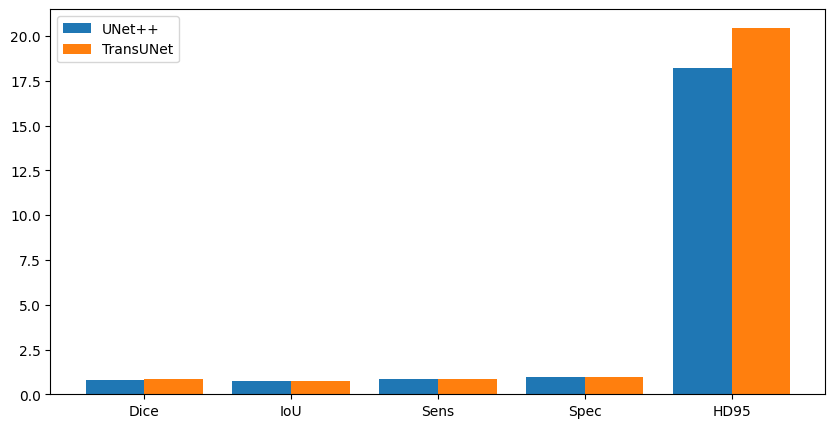

In [ ]:
#comparison between unet++ and transunet

print("\n" + "═"*50)
print(f" COMPARISON")
print("═"*50)
print(f"{'Metric':<10} {'UNet++':<15} {'TransUNet':<15}")
print("-" * 50)
for k in res_up:
    print(f"{k:<10} {res_up[k]:<15.4f} {res_tu[k]:<15.4f}")
print("═"*50)

plt.figure(figsize=(10, 5))
plt.bar(np.arange(len(res_up))-0.2, list(res_up.values()), 0.4, label='UNet++')
plt.bar(np.arange(len(res_tu))+0.2, list(res_tu.values()), 0.4, label='TransUNet')
plt.xticks(np.arange(len(res_up)), list(res_up.keys()))
plt.legend()
plt.savefig(os.path.join(RESULT_DIR, 'Comparison', 'metrics_comparison.png'))
plt.show()



🖼️  Generating Prediction Comparison Gallery...


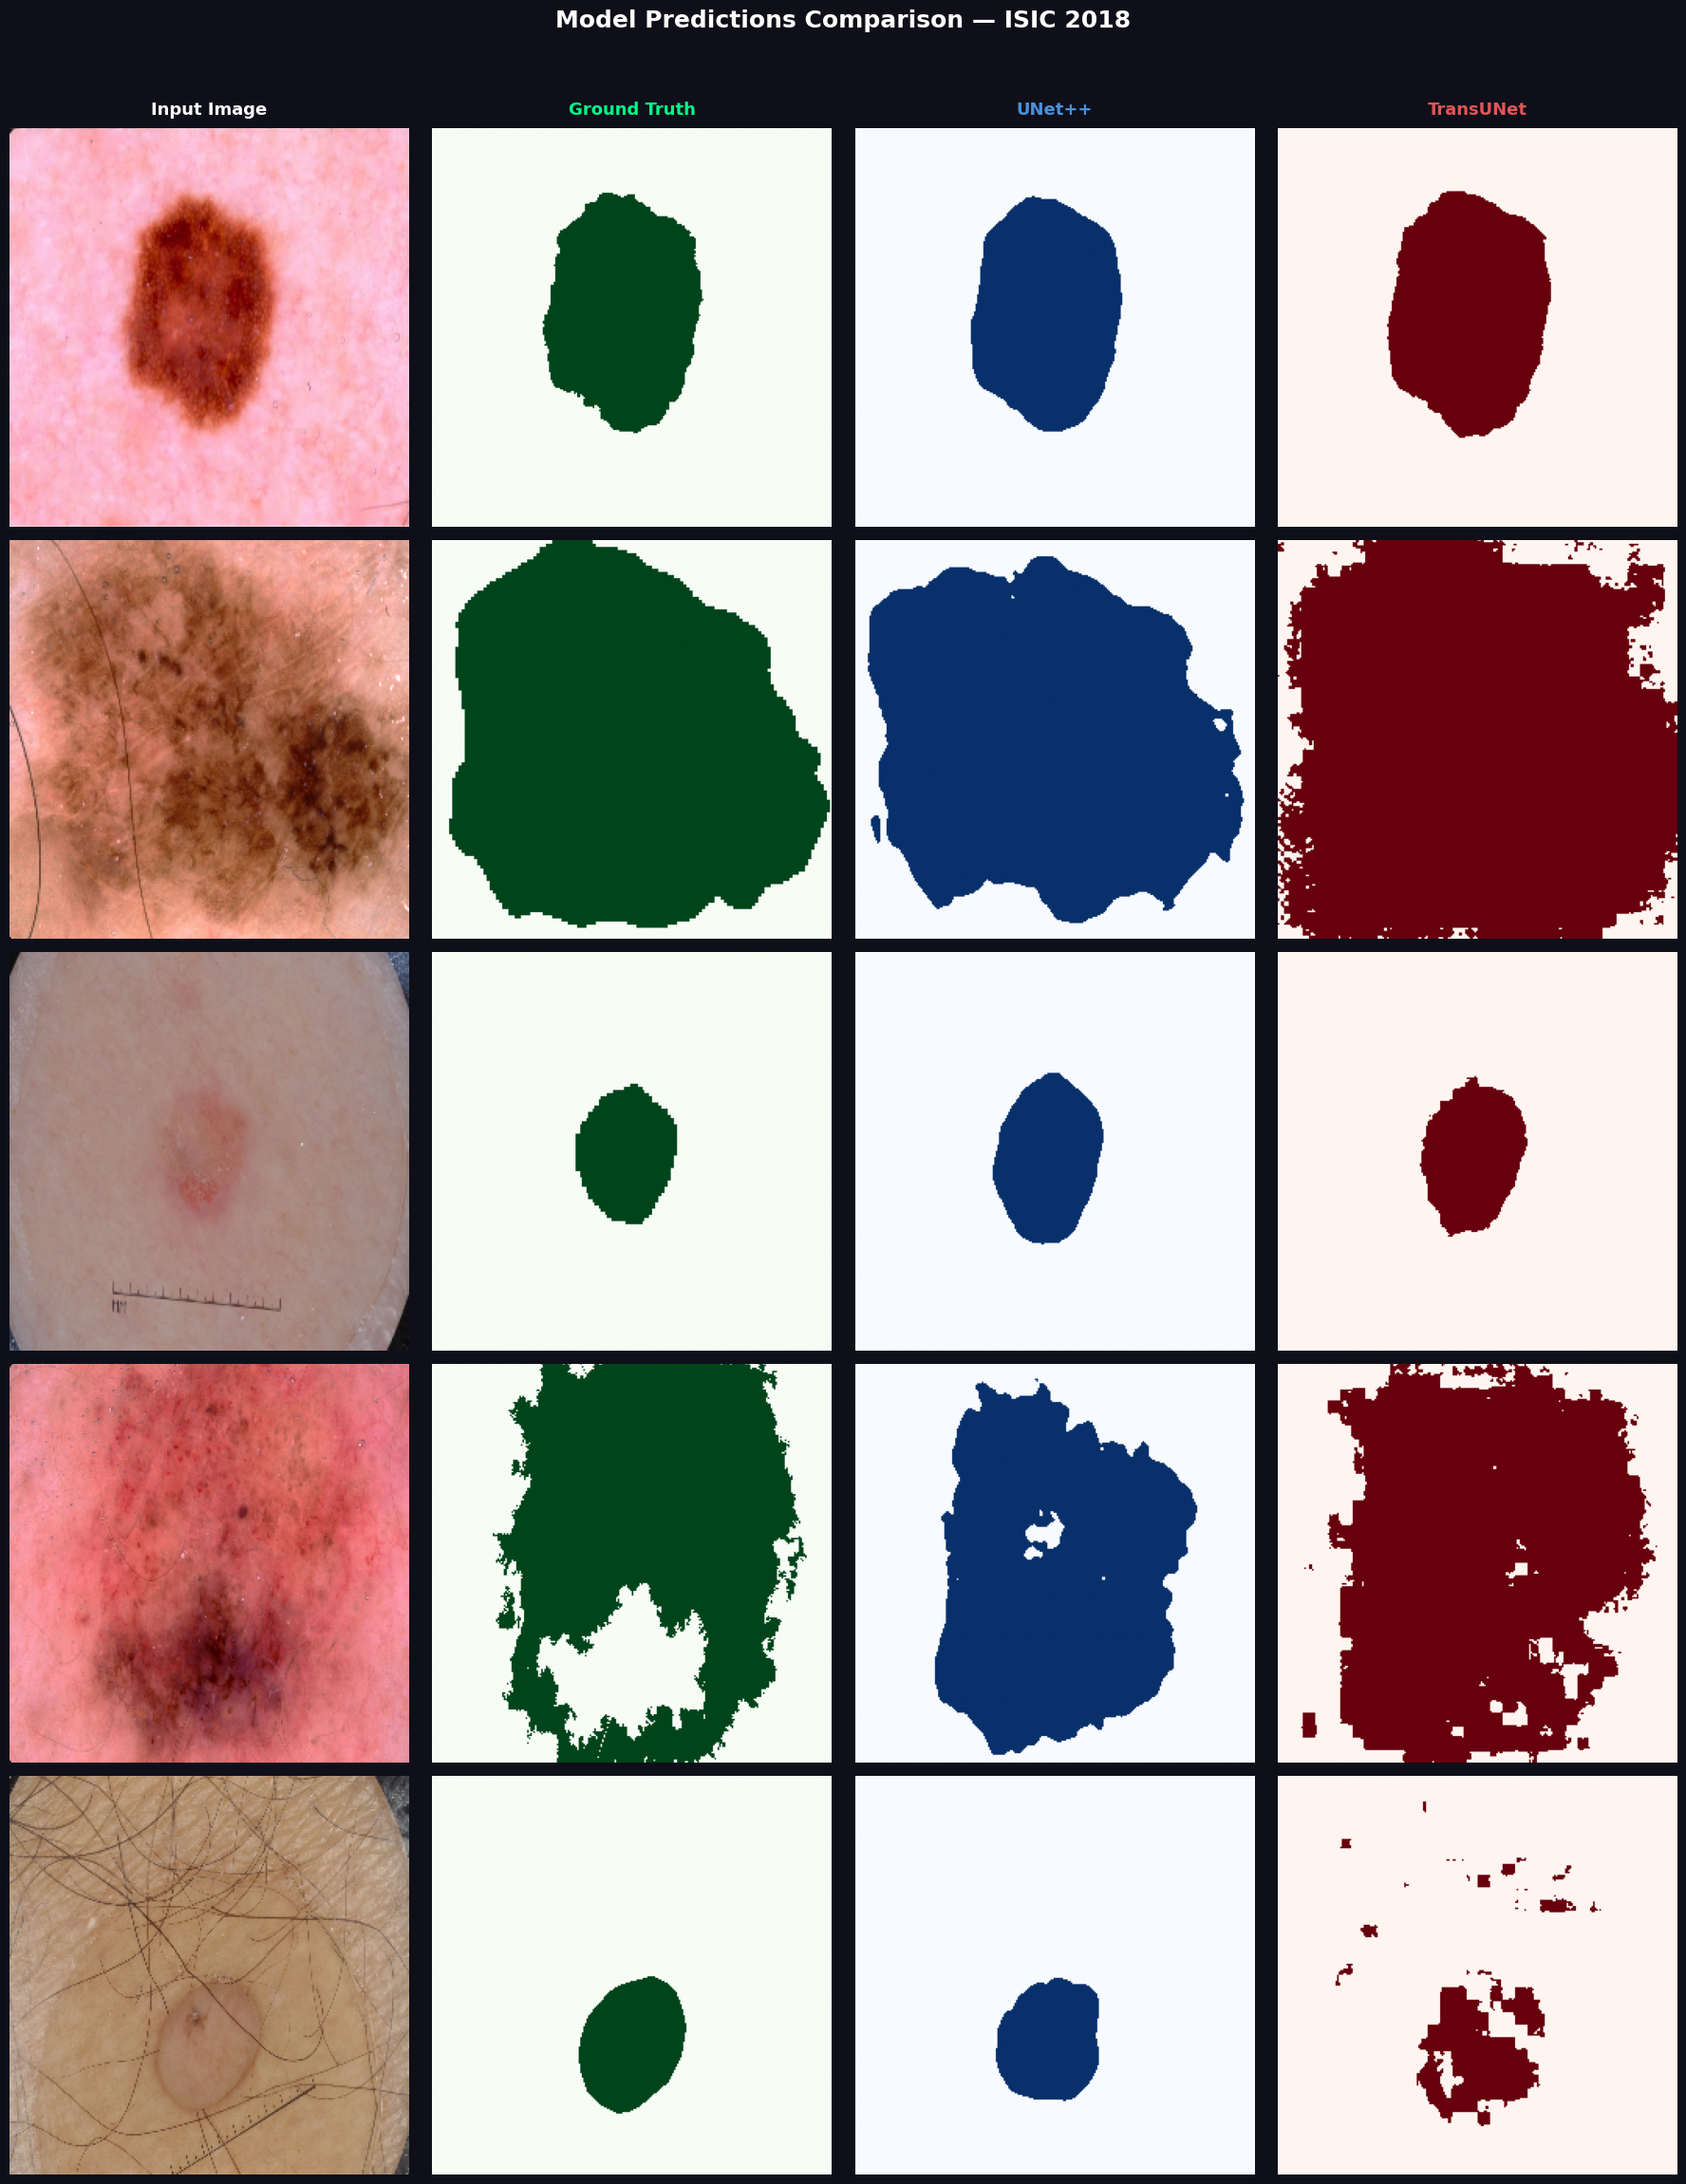

🖼️  Gallery saved to ./results/Comparison/prediction_comparison.png

✅ ALL TASKS COMPLETE
Results organized in: ./results/


In [ ]:
#comparitive visualisation

@torch.no_grad()
def visualise_both(unetpp, transunet, loader, device, n=5):
    unetpp.to(device).eval(); transunet.to(device).eval()
    mn, sd = np.array([0.485,0.456,0.406]), np.array([0.229,0.224,0.225])
    samples = []

    for imgs, msks in loader:
        if len(samples) >= n: break
        imgs_d = imgs.to(device)
        u_out = unetpp(imgs_d)
        t_out = transunet(imgs_d)
        if isinstance(u_out, list): u_out = u_out[-1]

        samples.append((
            imgs[0].permute(1,2,0).cpu().numpy() * sd + mn,
            msks[0,0].cpu().numpy(),
            (torch.sigmoid(u_out[0,0]).cpu().numpy() > 0.5).astype(float),
            (torch.sigmoid(t_out[0,0]).cpu().numpy() > 0.5).astype(float),
        ))

    fig, axes = plt.subplots(n, 4, figsize=(18, 4.5*n))
    fig.patch.set_facecolor('#0f0f1a')
    titles = ['Input Image', 'Ground Truth', 'UNet++', 'TransUNet']
    colors = ['#ffffff', '#00ff88', '#4A90D9', '#E05656']
    cmaps  = [None, 'Greens', 'Blues', 'Reds']

    for row, (img, gt, up, tp) in enumerate(samples):
        data = [np.clip(img,0,1), gt, up, tp]
        for c, (d, cm) in enumerate(zip(data, cmaps)):
            ax = axes[row, c] if n > 1 else axes[c]
            ax.imshow(d, cmap=cm, vmin=0, vmax=1) if cm else ax.imshow(d)
            ax.axis('off')
            if row == 0:
                ax.set_title(titles[c], color=colors[c], fontsize=13, fontweight='bold', pad=10)

    plt.suptitle('Model Predictions Comparison — ISIC 2018', color='white', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout(pad=1.0)
    plt.savefig(os.path.join(RESULT_DIR, 'Comparison', 'prediction_comparison.png'), dpi=200, bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()
    print(f" Gallery saved to {RESULT_DIR}/Comparison/prediction_comparison.png")

visualise_both(unetpp, transunet, test_loader, device, n=5)
